# EDA dan Data Preprocessing

In [38]:
import pandas as pd
import numpy as np
import re

In [39]:
df = pd.read_excel('case_2_dataset.xlsx')
print(f"Total Baris: {df.shape[0]}")
print(f"Total Kolom: {df.shape[1]}")
print("\nKolom yang tersedia:\n", df.columns.tolist())

Total Baris: 15000
Total Kolom: 32

Kolom yang tersedia:
 ['date', 'lang', 'source', 'user_id', 'hashtags', 'is_quote', 'mentions', 'tweet_id', 'username', 'verified', 'full_text', 'created_at', 'quoted_url', 'view_count', 'quote_count', 'quoted_text', 'reply_count', 'display_name', 'retweet_count', 'user_location', 'favorite_count', 'in_reply_to_url', 'quoted_tweet_id', 'quoted_username', 'user_created_at', 'user_description', 'in_reply_to_user_id', 'user_statuses_count', 'user_followers_count', 'user_following_count', 'in_reply_to_status_id', 'in_reply_to_screen_name']


In [40]:
critical_cols = ['full_text', 'username', 'created_at', 'favorite_count', 'retweet_count']
print("\nMissing Values pada Kolom Kunci:")
print(df[critical_cols].isnull().sum())


Missing Values pada Kolom Kunci:
full_text         0
username          0
created_at        0
favorite_count    0
retweet_count     0
dtype: int64


In [41]:
print("\nTop 5 Tweet dengan Engagement Tertinggi (Favorite):")
print(df.sort_values(by='favorite_count', ascending=False)[['username', 'full_text', 'favorite_count']].head())

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


Top 5 Tweet dengan Engagement Tertinggi (Favorite):
            username                                          full_text  \
8112   VeronicaKoman  Gw udah duga program makan gratis bakal ditola...   
8218       PaltiWest  Yang ini lebih kasihan lagi.. Malah trauma jad...   
9881    karimakayyim  Anak-anak keracunan Makan Bergizi Gratis. Emak...   
14232        CakKhum  Tiba-tiba hari ini menunya MBG lebih lezat dar...   
10624     tempodotco  Curhat Ibu Kantin: Mulai Dagang Nasi sejak 198...   

       favorite_count  
8112            45829  
8218            30719  
9881            26660  
14232           25288  
10624           14245  


C:\Users\viyendra\AppData\Local\Temp\ipykernel_26004\806470687.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


In [42]:
def advanced_cleaning(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [43]:
df['clean_text'] = df['full_text'].apply(advanced_cleaning)

print("\nPreview Hasil Pembersihan:")
print(df[['full_text', 'clean_text']].head())


Preview Hasil Pembersihan:
                                           full_text  \
0  Surat Edaran (SE) Ditjen Pendis Kemenag Nomor ...   
1  PROGRAM MAKAN BERGIZI GRATIS UNTUK ANEUK ACEH\...   
2  @abu_waras @prabowo Sdh pertengahan Januari 20...   
3                 @bahlilngntot @tanyakanrl Agen mbg   
4  Program MBG = bukan bisnis. Ini gerakan sosial...   

                                          clean_text  
0  surat edaran se ditjen pendis kemenag nomor ta...  
1      program makan bergizi gratis untuk aneuk aceh  
2  sdh pertengahan januari sampai skrg blm ada li...  
3                                           agen mbg  
4  program mbg bukan bisnis ini gerakan sosial ya...  


# Sentimen Analysis

In [44]:
from transformers import pipeline
import torch
import pandas as pd

In [45]:
model_name = "indobenchmark/indobert-base-p1"

try:
    sentiment_pipe = pipeline(
        "sentiment-analysis", 
        model="StevenLimcorn/indobert-reborn-sentiment-analysis"
    )
except Exception as e:
    print(f"Model utama gagal dimuat, menggunakan model fallback...")
    sentiment_pipe = pipeline(
        "sentiment-analysis", 
        model="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
    )

def get_sentiment(text):
    if not text or len(text) < 5:
        return "neutral"
    try:
        result = sentiment_pipe(text[:512])[0]
        label = result['label'].lower()
        if 'pos' in label or 'joy' in label: return 'positive'
        if 'neg' in label or 'sad' in label or 'anger' in label: return 'negative'
        return 'neutral'
    except:
        return "neutral"


Model utama gagal dimuat, menggunakan model fallback...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [46]:
df['sentiment'] = df['clean_text'].apply(get_sentiment)

print("\n=== HASIL ANALISIS SENTIMEN ===")
print(df['sentiment'].value_counts())
print("\nPersentase:")
print(df['sentiment'].value_counts(normalize=True) * 100)


=== HASIL ANALISIS SENTIMEN ===
sentiment
negative    7627
positive    7096
neutral      277
Name: count, dtype: int64

Persentase:
sentiment
negative    50.846667
positive    47.306667
neutral      1.846667
Name: proportion, dtype: float64


# Social Network Analysis

In [47]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community

In [48]:
def extract_mentions(text):
    if not isinstance(text, str): return []
    return re.findall(r'@(\w+)', text)

In [49]:
df['mentions_list'] = df['full_text'].apply(extract_mentions)

edges = []
for idx, row in df.iterrows():
    sender = row['username']
    for receiver in row['mentions_list']:
        if sender != receiver: 
            edges.append((sender, receiver))

G = nx.DiGraph() 
G.add_edges_from(edges)

print(f"Graf berhasil dibangun: {G.number_of_nodes()} Aktor, {G.number_of_edges()} Interaksi.")

Graf berhasil dibangun: 10434 Aktor, 12311 Interaksi.


In [50]:
centrality = nx.in_degree_centrality(G)

top_actors = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n=== TOP 10 AKTOR PALING BERPENGARUH (MOST MENTIONED) ===")
for user, score in top_actors:
    print(f"@{user:20} | Score: {score:.4f}")


=== TOP 10 AKTOR PALING BERPENGARUH (MOST MENTIONED) ===
@prabowo              | Score: 0.0666
@ARSIPAJA             | Score: 0.0386
@kompascom            | Score: 0.0224
@txtdrimedia          | Score: 0.0204
@tempodotco           | Score: 0.0160
@multibank_io         | Score: 0.0115
@DS_yantie            | Score: 0.0114
@CNNIndonesia         | Score: 0.0104
@tanyarlfes           | Score: 0.0100
@Gerindra             | Score: 0.0092


In [51]:
communities = list(community.greedy_modularity_communities(G.to_undirected()))

print(f"\nTerdeteksi {len(communities)} komunitas besar dalam percakapan MBG.")

for i, comm in enumerate(communities[:5]):
    print(f"Komunitas {i+1}: {len(comm)} anggota")


Terdeteksi 1455 komunitas besar dalam percakapan MBG.
Komunitas 1: 1191 anggota
Komunitas 2: 481 anggota
Komunitas 3: 474 anggota
Komunitas 4: 437 anggota
Komunitas 5: 433 anggota


# Topic Modelling

In [52]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [53]:
tf_vectorizer = CountVectorizer(max_df=0.90, min_df=5, max_features=1000)

df['clean_text'] = df['clean_text'].fillna("")
tf_matrix = tf_vectorizer.fit_transform(df['clean_text'])

In [54]:
num_topics = 4
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42, max_iter=10)
lda_model.fit(tf_matrix)

,n_components,4
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [55]:
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopik {topic_idx + 1}:")
        # Mengambil indeks kata dengan bobot probabilitas tertinggi di topik ini
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        
        print(" | ".join(top_features))

In [ ]:
print("\n=== HASIL EKSTRAKSI TEMA MBG ===")
tf_feature_names = tf_vectorizer.get_feature_names_out()
print_top_words(lda_model, tf_feature_names, n_top_words=10)

# 4. Memasukkan label topik dominan kembali ke dataset untuk analisis lanjutan
topic_distributions = lda_model.transform(tf_matrix)
df['dominant_topic'] = topic_distributions.argmax(axis=1) + 1


=== HASIL EKSTRAKSI TEMA MBG ===

Topik 1:
program | anak | mbg | bergizi | makan | gratis | dan | gizi | untuk | indonesia

Topik 2:
mbg | dan | yang | di | program | ini | untuk | dari | keracunan | tidak

Topik 3:
makan | gratis | bergizi | sekolah | di | mbg | anak | program | dan | ini

Topik 4:
mbg | yg | itu | ada | ga | ini | aja | buat | ya | di

[SUKSES] Label topik dominan telah ditambahkan ke kolom 'dominant_topic' pada dataset.


# Insight dan Export

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
topic_sentiment = pd.crosstab(df['dominant_topic'], df['sentiment'], normalize='index') * 100

print("\nPersentase Sentimen dalam Setiap Topik (%):")
print(topic_sentiment.round(2))


Persentase Sentimen dalam Setiap Topik (%):
sentiment       negative  neutral  positive
dominant_topic                             
1                   8.54     0.55     90.91
2                  51.28     2.61     46.11
3                  25.95     1.74     72.32
4                  73.96     1.94     24.11


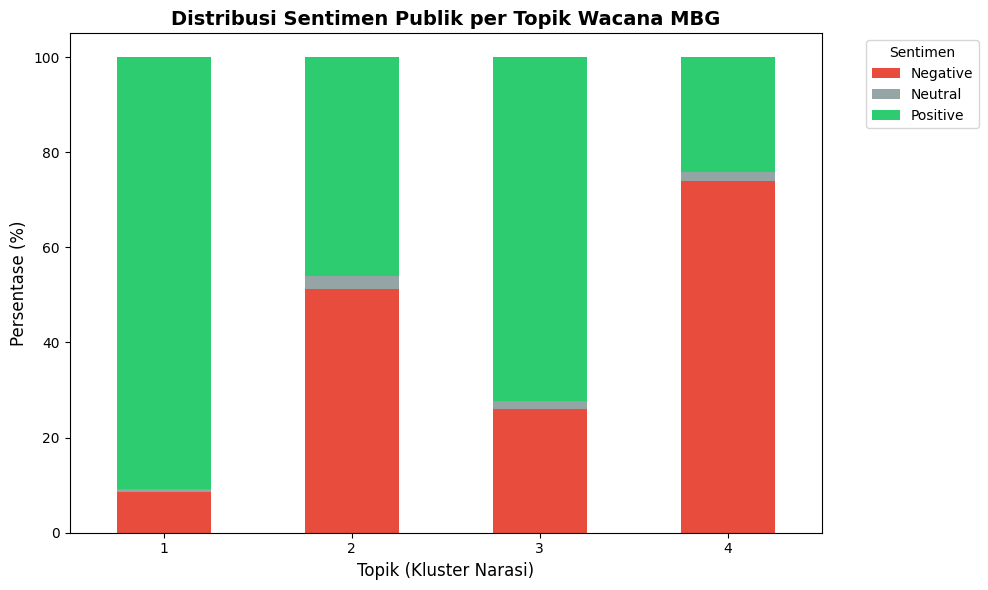

In [59]:
plt.figure(figsize=(10, 6))
topic_sentiment.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=plt.gca())
plt.title('Distribusi Sentimen Publik per Topik Wacana MBG', fontsize=14, fontweight='bold')
plt.xlabel('Topik (Kluster Narasi)', fontsize=12)
plt.ylabel('Persentase (%)', fontsize=12)
plt.legend(title='Sentimen', labels=['Negative', 'Neutral', 'Positive'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Insight_Sentimen_Topik_MBG.png', dpi=300)

In [60]:
final_cols = [
    'created_at', 'username', 'clean_text', 'favorite_count', 
    'retweet_count', 'mentions_list', 'sentiment', 'dominant_topic'
]

available_cols = [col for col in final_cols if col in df.columns]
df_final = df[available_cols]

output_file = 'BDC_Case2_KEREN.csv'
df_final.to_csv(output_file, index=False)